### **Import Libraries**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

### **Import Data**

In [2]:
df = pd.read_excel(r'swiggy_data.xlsx')

In [3]:
df.head()

,State,City,Order Date,Restaurant Name,Location,Category,Dish Name,Price (INR),Rating,Rating Count
0,Karnataka,Bengaluru,2025-06-29,Anand Sweets & Savouries,Rajarajeshwari Nagar,Snack,Butter Murukku-200gm,133.9,4.0,0
1,Karnataka,Bengaluru,2025-04-03,Srinidhi Sagar Deluxe,Kengeri,Recommended,Badam Milk,52.0,4.5,25
2,Karnataka,Bengaluru,2025-01-15,Srinidhi Sagar Deluxe,Kengeri,Recommended,Chow Chow Bath,117.0,4.7,48
3,Karnataka,Bengaluru,2025-04-17,Srinidhi Sagar Deluxe,Kengeri,Recommended,Kesari Bath,65.0,4.6,65
4,Karnataka,Bengaluru,2025-03-13,Srinidhi Sagar Deluxe,Kengeri,Recommended,Mix Raitha,130.0,4.0,0


In [4]:
df.tail()

,State,City,Order Date,Restaurant Name,Location,Category,Dish Name,Price (INR),Rating,Rating Count
197425,Sikkim,Gangtok,2025-01-25,Mama's Kitchen,Gangtok,Momos,Soya cheese chilli momo ...,112.0,4.4,0
197426,Sikkim,Gangtok,2025-07-02,Mama's Kitchen,Gangtok,Momos,Kurkure momo fried ...,140.0,4.4,0
197427,Sikkim,Gangtok,2025-03-25,Mama's Kitchen,Gangtok,Momos,Chilli cheese momo,126.0,4.4,0
197428,Sikkim,Gangtok,2025-03-26,Mama's Kitchen,Gangtok,Momos,Veg Momos (8 Pc),85.0,4.4,0
197429,Sikkim,Gangtok,2025-03-27,Mama's Kitchen,Gangtok,Momos,Soya Momo,100.0,4.4,0


### **Data Viewing**

In [5]:
print("No. of Rows: ", df.shape[0])
print("No. of Columns: ", df.shape[1])

No. of Rows:  197430
No. of Columns:  10


In [6]:
df.info

<bound method DataFrame.info of             State       City Order Date           Restaurant Name  \
0       Karnataka  Bengaluru 2025-06-29  Anand Sweets & Savouries   
1       Karnataka  Bengaluru 2025-04-03     Srinidhi Sagar Deluxe   
2       Karnataka  Bengaluru 2025-01-15     Srinidhi Sagar Deluxe   
3       Karnataka  Bengaluru 2025-04-17     Srinidhi Sagar Deluxe   
4       Karnataka  Bengaluru 2025-03-13     Srinidhi Sagar Deluxe   
...           ...        ...        ...                       ...   
197425     Sikkim    Gangtok 2025-01-25            Mama's Kitchen   
197426     Sikkim    Gangtok 2025-07-02            Mama's Kitchen   
197427     Sikkim    Gangtok 2025-03-25            Mama's Kitchen   
197428     Sikkim    Gangtok 2025-03-26            Mama's Kitchen   
197429     Sikkim    Gangtok 2025-03-27            Mama's Kitchen   

                    Location     Category  \
0       Rajarajeshwari Nagar        Snack   
1                    Kengeri  Recommended   
2   

### **Data Types**

In [7]:
df.dtypes

State                      object
City                       object
Order Date         datetime64[ns]
Restaurant Name            object
Location                   object
Category                   object
Dish Name                  object
Price (INR)               float64
Rating                    float64
Rating Count                int64
dtype: object

In [8]:
df.describe()

,Order Date,Price (INR),Rating,Rating Count
count,197430,197430.000000,197430.000000,197430.000000
mean,2025-05-01 19:41:20.996808960,268.512920,4.341582,28.321805
min,2025-01-01 00:00:00,0.950000,1.500000,0.000000
25%,2025-03-01 00:00:00,139.000000,4.300000,0.000000
50%,2025-05-02 00:00:00,229.000000,4.400000,2.000000
75%,2025-07-01 00:00:00,329.000000,4.500000,15.000000
max,2025-08-31 00:00:00,8000.000000,5.000000,999.000000
std,NaN,219.338363,0.422585,87.542593


### **KPI's**

#### Total Sales

In [9]:
total_sales = df['Price (INR)'].sum()
print("Total Sales (INR): ", round(total_sales,2))

Total Sales (INR):  53012505.77


#### Average Rating

In [10]:
avg_rating = df['Rating'].mean()
print("Average Rating: ", round(avg_rating,1))

Average Rating:  4.3


#### Average Order Value (₹)

In [11]:
avg_ord_val = df['Price (INR)'].mean()
print("Average Order Value (₹): ", round(avg_ord_val,2))

Average Order Value (₹):  268.51


#### Ratings Count

In [12]:
cust_rev = df['Rating Count'].sum()
print("Ratings Count: ", cust_rev)

Ratings Count:  5591574


#### Total Orders

In [13]:
total_ord = len(df)
print("Total Orders: ", total_ord)       #Another way df.shape[0]

Total Orders:  197430


### **Data Visualization**

#### Monthly Sales Trend

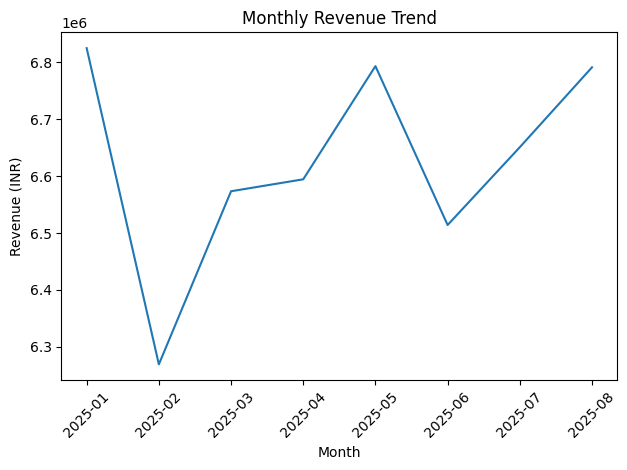

In [14]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['YearMonth'] = df['Order Date'].dt.to_period("M").astype(str)
monthly_revenue = df.groupby("YearMonth")['Price (INR)'].sum().reset_index()

plt.figure()
plt.plot(monthly_revenue['YearMonth'],monthly_revenue['Price (INR)'])
plt.xticks(rotation = 45)
plt.xlabel("Month")
plt.ylabel("Revenue (INR)")
plt.title("Monthly Revenue Trend")
plt.tight_layout()
plt.show()

#### Daily Sales Trend

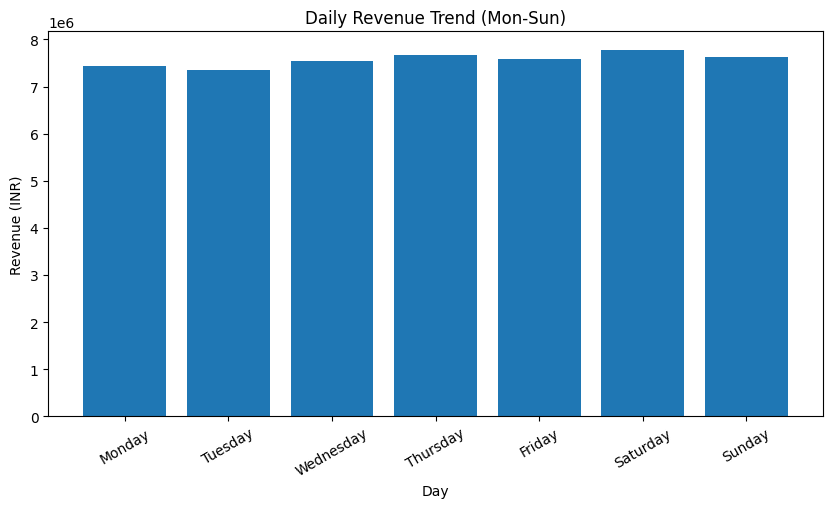

In [15]:
df['DayName'] = pd.to_datetime(df["Order Date"]).dt.day_name()

daily_revenue = (df.groupby("DayName")['Price (INR)'].sum().reindex(['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday',"Sunday"]))

plt.figure(figsize=(10,5))
plt.bar(daily_revenue.index,daily_revenue.values)
plt.title("Daily Revenue Trend (Mon-Sun)")
plt.xlabel("Day")
plt.ylabel("Revenue (INR)")
plt.xticks(rotation = 30)
plt.show()

#### Total Sales by Food Type (Veg or Non-Veg)

In [16]:
non_veg_keywords = [
  "chicken", "egg", "fish", "mutton",
  "prawn", 'biryani','kabab','kebab',
  'non-veg',"non veg"
]

df['Food Category'] = np.where(
  df['Dish Name'].str.lower().str.contains("|".join(non_veg_keywords), na=False),
  "Non-Veg",
  "Veg"
)

In [17]:
food_revenue = (
  df.groupby("Food Category")['Price (INR)'].sum().reset_index()
)

In [18]:
# Pie chart
fig = px.pie(
    food_revenue,
    names="Food Category",
    values="Price (INR)",
    hole=0.5,
    title="Revenue Contribution: Veg vs Non-Veg"
)

# Customize hover 
fig.update_traces(
    textinfo="percent+label",
    pull = [0.05, 0]
)

# Update layout
fig.update_layout(
    height = 500,
    margin = dict(t=60, b=40, l=40, r=40)
)

fig.show()

#### Total Sales by State

In [19]:
# Groupby + sort
state_sales = df.groupby("State", as_index=False)['Price (INR)'].sum().sort_values("Price (INR)", ascending=True)

# Create horizontal bar chart
fig = px.bar(
    state_sales,
    x="Price (INR)",
    y="State",
    orientation="h",
    text="Price (INR)",
    color="Price (INR)",
    color_continuous_scale="Blues",
    title="Revenue by State (INR)",
    height=600
)

# Customize text & hover
fig.update_traces(
    texttemplate="₹%{x:,.0f}",
    textposition='inside',
    hovertemplate="<b>%{y}</b><br>Total Revenue: ₹%{x:,.0f>"
)

# Update layout for better design
fig.update_layout(
    yaxis=dict(autorange="reversed"),  # largest on top
    margin=dict(t=80, b=40, l=120, r=40),
    plot_bgcolor='white',
    paper_bgcolor='white',
    title=dict(
        text="Revenue by State (INR)",
        x=0.5,
        xanchor='center',
        font=dict(size=22)
    ),
    coloraxis_colorbar=dict(
        title="Revenue (₹)"
    )
)

fig.show()

#### Quarterly Performance Summary 

In [20]:
# Ensure Order Date is datetime
df['Order Date'] = pd.to_datetime(df['Order Date'])

# Create Quarter column
df['Quarter'] = df['Order Date'].dt.to_period('Q').astype(str)

# Group by Quarter and calculate metrics
quarterly_summary = df.groupby('Quarter', as_index=False).agg(
    total_sales=('Price (INR)', 'sum'),
    avg_rating=('Rating', 'mean'),
    total_ord=('Order Date', 'count')
).sort_values('Quarter')

quarterly_summary['total_sales'] = quarterly_summary['total_sales'].round(0)
quarterly_summary['avg_rating'] = quarterly_summary['avg_rating'].round(2)

quarterly_summary

,Quarter,total_sales,avg_rating,total_ord
0,2025Q1,19667822.0,4.34,73096
1,2025Q2,19902257.0,4.34,74163
2,2025Q3,13442427.0,4.34,50171


#### Top 5 Cities by Sales

In [26]:
top_five_cities = (
  df.groupby("City")['Price (INR)']
  .sum()
  .nlargest(5)
  .sort_values()
  .reset_index()
)

fig = px.bar(
  top_five_cities,
  x = "Price (INR)",
  y = "City",
  orientation= "h",
  title= "Top 5 Cities by Sales (INR)",
  color_discrete_sequence=['#264653']
)

fig.show()

#### Weekly Revenue Trend

In [25]:
df['Week Number'] = pd.to_datetime(df['Order Date']).dt.isocalendar().week

weekly_revenue = (
  df.groupby("Week Number") ["Price (INR)"].sum().reset_index()
)


#Bar Chart
fig = px.bar(weekly_revenue, x = "Week Number", y = "Price (INR)", title="Weekly Revenue Trend", color_discrete_sequence=['#2a9d8f'])

fig.show()